# 10 - Machine Learning: scrap rate prediction

**Question this model answers:** given the machine, mold, operator, and
shift for an order about to run, how much scrap (rejected pieces)
should I expect -- and which of those factors matters most?

The most useful output here isn't the predicted number itself, it's the
**feature importance** ranking -- it shows where to look to actually
reduce scrap.


In [8]:
import sys
sys.path.insert(0, "../machine_learning")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import ml_lib as ml

PROCESSED = "../../datasets/processed"
MODELS = "../../models"
REPORTS = "../../reports"
os.makedirs(MODELS, exist_ok=True)

production = pd.read_csv(f"{PROCESSED}/fact_production_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
production["ScrapRatePct"] = production["RejectedQty"] / production["ProducedQty"] * 100

print(f"Rows: {len(production)}")
print(f"Scrap rate -- mean: {production['ScrapRatePct'].mean():.2f}%, "
      f"median: {production['ScrapRatePct'].median():.2f}%, max: {production['ScrapRatePct'].max():.2f}%")


Rows: 9110
Scrap rate -- mean: 2.38%, median: 2.09%, max: 19.86%


## Step 1: choose the features (only before/during-order conditions)

I only use information that already exists **before** knowing the
order's outcome (machine, mold, operator, shift, run time,
availability, performance) -- never a column that's already derived
from scrap itself (like `Quality`, which uses `RejectedQty` in its
calculation -- that would let the model "cheat").


In [9]:
input_columns = [
    "Process", "MachineId", "ToolId", "OperatorId", "ShiftNumber",
    "RunTimeHours", "SetupTimeHours", "Availability", "Performance", "MaterialLotSeq",
]
target_column = "ScrapRatePct"

model_data = production[["Date"] + input_columns + [target_column]].dropna().copy()

# turns the text columns (Process, MachineId, ToolId, OperatorId) into
# 0/1 columns, one per category -- this is what the model can actually work with
model_data = pd.get_dummies(
    model_data, columns=["Process", "MachineId", "ToolId", "OperatorId"], drop_first=True
)

feature_columns = [c for c in model_data.columns if c not in ("Date", target_column)]
print(f"Model data: {len(model_data)} rows, {len(feature_columns)} features")


Model data: 8941 rows, 174 features


## Step 2: train/test split and a simple baseline

In [10]:
train, test = ml.split_by_date(model_data, "Date", test_fraction=0.2)
X_train, y_train = train[feature_columns], train[target_column]
X_test, y_test = test[feature_columns], test[target_column]
print(f"Train: {len(train)} rows | Test: {len(test)} rows")

baseline_prediction = np.full(len(y_test), y_train.mean())
print("\nSimple baseline (plant-wide historical average):")
print(ml.regression_metrics(y_test, baseline_prediction))


Train: 7152 rows | Test: 1789 rows

Simple baseline (plant-wide historical average):
{'MAE': 1.4581487446377837, 'RMSE': np.float64(2.2078248457832688), 'MAPE_%': np.float64(280.4152917961049), 'R2': -0.0001271363725667829}


## Step 3: train the model

In [11]:
model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)
print("Random Forest:")
print(ml.regression_metrics(y_test, prediction))


Random Forest:
{'MAE': 0.6953508208617871, 'RMSE': np.float64(1.0628848066914578), 'MAPE_%': np.float64(35.06328498923092), 'R2': 0.7682080353196153}


## Step 4: feature importance -- where does scrap come from?

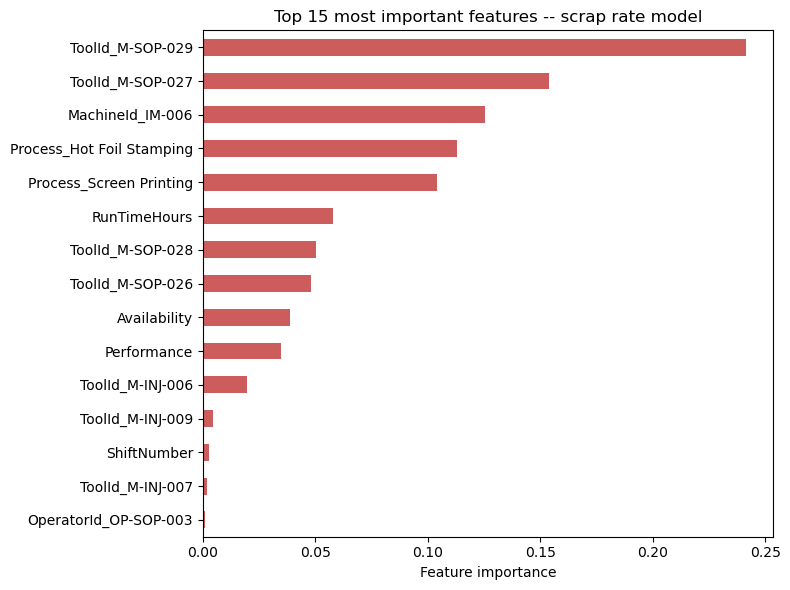

In [12]:
importance = pd.Series(model.feature_importances_, index=feature_columns)
importance = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("Feature importance")
ax.set_title("Top 15 most important features -- scrap rate model")
plt.tight_layout()
plt.savefig(f"{REPORTS}/37_ml_scrap_feature_importance.png", dpi=150)
plt.show()


## Step 5: actual vs. predicted, and save the model

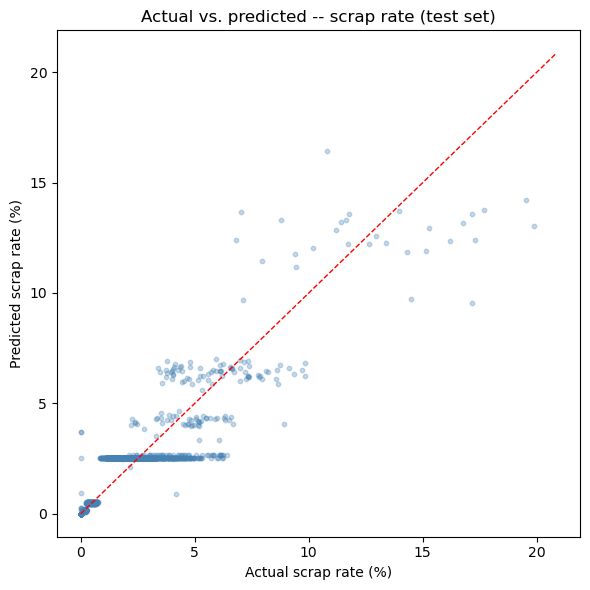

Model saved to ../../models/scrap_rate_model.pkl


In [13]:
test = test.copy()
test["Predicted"] = prediction

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test[target_column], test["Predicted"], alpha=0.3, s=10, color="steelblue")
limit = max(test[target_column].max(), test["Predicted"].max()) * 1.05
ax.plot([0, limit], [0, limit], "r--", linewidth=1)  # "perfect prediction" line
ax.set_xlabel("Actual scrap rate (%)")
ax.set_ylabel("Predicted scrap rate (%)")
ax.set_title("Actual vs. predicted -- scrap rate (test set)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/38_ml_scrap_actual_vs_predicted.png", dpi=150)
plt.show()

ml.save_model(
    model, f"{MODELS}/scrap_rate_model.pkl",
    feature_cols=feature_columns, target_col=target_column, model_name="Random Forest",
    test_metrics=ml.regression_metrics(y_test, test["Predicted"]),
)
print(f"Model saved to {MODELS}/scrap_rate_model.pkl")


## Step 6: export the results

In [14]:
exported_predictions = test[["Date", target_column, "Predicted"]].rename(columns={
    target_column: "ActualScrapRatePct", "Predicted": "PredictedScrapRatePct",
})
exported_predictions.to_csv(f"{PROCESSED}/ml_predictions_scrap_rate.csv", index=False, encoding="utf-8-sig")
print(f"Exported ml_predictions_scrap_rate.csv ({len(exported_predictions)} rows)")


Exported ml_predictions_scrap_rate.csv (1789 rows)


## Summary

The model does clearly better than just guessing the historical
average (high R² vs. R²≈0 for the baseline). More useful than the
number itself: the feature importance list turns "scrap is high" into
"scrap is high specifically on these machine/mold combinations" --
something a continuous-improvement team can actually act on.
